MODULO DEEP LEARNING

**FASE 1: ENTENDIMIENTO DEL NEGOCIO**

1.1 Resumen

* El conjunto de datos presenta transacciones que ocurrieron en dos días, donde tenemos 492 fraudes de 284.807 transacciones.
* El conjunto de datos está altamente desequilibrado.

Variables:
*   V1, V2,... V28 -> son los componentes principales obtenidos con PCA
*   Tiempo y Cantidad 
* Tiempo -> contiene los segundos transcurridos entre cada transacción y la primera transacción en el conjunto de datos.
* Amount -> Monto de la transacción
* Clase -> Variable de respuesta(Target) donde 1 = Fraude, 0 = No Fraude

1.2 Objetivo

Identificar los clientes propensos a realizar transacciones
fraudulentas.

**FASE 2: COMPRENSION DE LOS DATOS**

2.1 Configuracion e Importacion de Librerias

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Tensorflow and Keras
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import AUC, Precision, Recall

I0000 00:00:1787690421.126531  298489 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787690421.167089  298489 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/andres/miniconda3/envs/mlops_fraudulent_transactions/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.21) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for go

In [3]:
# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score, 
    roc_auc_score, 
    f1_score, 
    precision_score, 
    recall_score, 
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [4]:
# Imbalanced-learn
from imblearn.over_sampling import SMOTE

ModuleNotFoundError: No module named 'imblearn'

In [5]:
# No mostrar warnings 
import warnings
warnings.filterwarnings("ignore")

2.2 Carga y Exploracion de Datos (EDA)

In [6]:
# Cargar  y visualizar los datos
df = pd.read_csv('./../data/raw/creditcard.csv')
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [9]:
# Filter only fraudulent transactions
fraud_df = df[df['Class'] == 1]
fraud_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


In [11]:
# See complete row of the first two fraudulent transactions
fraud_df.head(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.0,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.0,1


In [89]:
# Verificar si hay valores nulos en el DataFrame
df.isnull().sum() 

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [90]:
# Ver información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [91]:
# Revisamos las dimensiones del dataset
df.shape

(284807, 31)

In [92]:
#Revisamos el target(Class) y su distribución
# 1 = Fraude
# 0 = No Fraude
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

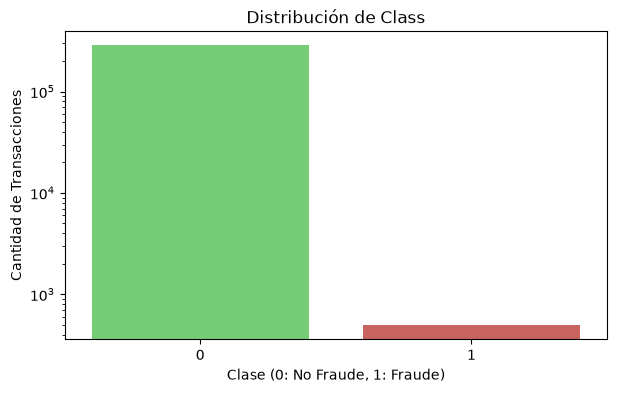

In [93]:
# Gráfico para verificar el desbalance
plt.figure(figsize=(7, 4))
sns.countplot(x='Class', data=df, palette=["#67db67", '#d9534f'])
plt.yscale('log')
plt.title('Distribución de Class')
plt.xlabel('Clase (0: No Fraude, 1: Fraude)')
plt.ylabel('Cantidad de Transacciones')
plt.show()

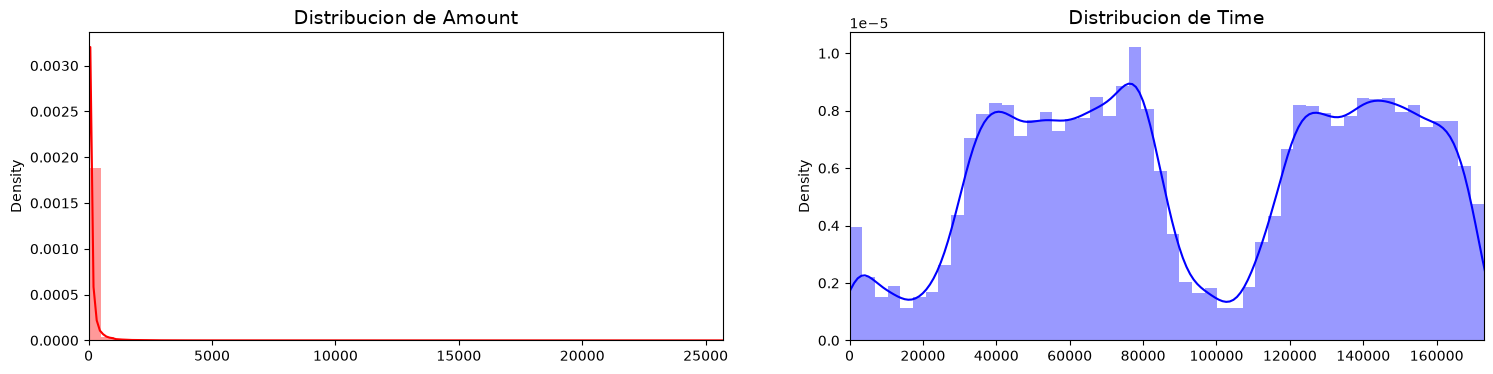

In [94]:
# Verificar la distribución de las variables 'Amount' y 'Time'
fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Distribucion de Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

sns.distplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Distribucion de Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])

plt.show()


In [95]:
# Revisamos los estadísticos de las variables numéricas
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**FASE 3: PREPARACION DE LOS DATOS**

3.1 Escalamiento de datos

In [96]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [97]:
X = df.drop('Class', axis=1)
y = df['Class']

#Separar el 20% para Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Separar el resto en Train (80% del 80% = 64%) y Validation (20% del 80% = 16%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

In [98]:
# Escalamiento de las variables
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [99]:
# Balanceo de datos antes de aplicar SMOTE
print(pd.Series(y_train).value_counts())

Class
0    170588
1       295
Name: count, dtype: int64


In [100]:
# Aplicar SMOTE para Evitar el desequilibrio de clases solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [101]:
# Balanceo de datos después de aplicar SMOTE
print(pd.Series(y_train_res).value_counts())

Class
0    170588
1    170588
Name: count, dtype: int64


**FASE 4: MODELADO**

4.1 Multilayer Perceptron(MLP)

In [102]:
input_dim = X_train_scaled.shape[1]

# Para evitar detener el entrenamiento si no hay mejora
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [103]:
mlp_model = Sequential([
    # Capa 1: Captura de patrones iniciales
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),  # Estabiliza el aprendizaje
    Dropout(0.3),

    # Capa 2: Abstracción intermedia
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Capa 3: Abstracción profunda
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Capa de salida
    Dense(1, activation='sigmoid')
])

In [104]:
#Compilado del modelo(Optimizer adam)
# metrics=['accuracy'] No es la mejor metrica para problemas desbalanceados.
# bIN

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[
    Recall(name='recall'),            # ¿Qué porcentaje de los fraudes reales detectamos?
    Precision(name='precision'),      # De los declarados como fraude, ¿cuántos lo son realmente?
    AUC(curve='PR', name='pr_auc'),   # Área bajo la curva Precision-Recall (La métrica estrella en fraude)
    AUC(curve='ROC', name='roc_auc')  # Área bajo la curva ROC
])

In [105]:
#Resumen de la estructura del modelo
mlp_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [106]:
#val_pr_auc-> 

# Guardamos el mejor modelo basado en la métrica de validación
checkpoint_mlp = ModelCheckpoint('../models/mlp_model.keras', monitor='val_pr_auc', mode='max', save_best_only=True)
early_stop_mlp = EarlyStopping(monitor='val_pr_auc', mode='max', patience=5, restore_best_weights=True)

In [107]:
#validation_split=0.2, #No es necesario ya que estamos usando validation_data

#Entrenamiento de la red neuronal
mlp_model.fit(
    X_train_res, y_train_res, #Datos balanceados con SMOTE
    validation_data=(X_val_scaled, y_val), # Datas de validacion reales
    epochs=100, # Numero de iteraciones que se ejecutara el entrenamiento
    batch_size=2048, #Tamano del lote de datos que se procesará en cada iteración
    callbacks=[early_stop_mlp, checkpoint_mlp],
    verbose=0
)

In [108]:
# Predicciones DL 1
y_proba_mlp = mlp_model.predict(X_test_scaled).ravel() #Ravel() convierte el array 2D en 1D
y_pred_mlp = (y_proba_mlp > 0.5).astype(int) # astype(int) convierte los valores booleanos en enteros (0 o 1)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


4.2 Autoencoder

In [ ]:
# NO se debe usar SMOTE en un Autoencoder
# Modelo no supervisado (Autoencoder) para detección de anomalías
# Autoencoder se entrena ÚNICAMENTE con transacciones normales/legítimas(no Fraude)
# Detección de anomalías: El autoencoder aprende a reconstruir las transacciones normales
# Ejemplo: Intenta imitar las transacciones legítimas y, si no puede reconstruir bien una transacción, es probable que sea fraudulenta.

# Arquitectura del Autoencoder
input_layer = Input(shape=(input_dim,))
encoder = Dense(16, activation='relu')(input_layer)
encoder = Dense(8, activation='relu')(encoder) #Cuello de botella
decoder = Dense(16, activation='relu')(encoder)
decoder = Dense(input_dim, activation='linear')(decoder)

In [110]:
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [111]:
#Resumen de la estructura del modelo
autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286 (5.02 KB)

 Trainable params: 1,286 (5.02 KB)

 Non-trainable params: 0 (0.00 B)

In [112]:
#val_pr_auc-> 

# Guardamos el mejor modelo basado en la métrica de validación
checkpoint_mlp = ModelCheckpoint('../models/mlp_model.keras', monitor='val_pr_auc', mode='max', save_best_only=True)
early_stop_mlp = EarlyStopping(monitor='val_pr_auc', mode='max', patience=5, restore_best_weights=True)

In [113]:
# Guardamos el mejor modelo basado en la métrica de validación
checkpoint_ae = ModelCheckpoint('../models/autoencoder_model.keras', monitor='val_loss', mode='min', save_best_only=True)
early_stop_ae = EarlyStopping(monitor='val_loss', mode='min', patience=5, restore_best_weights=True)

In [114]:
# Filtrar solo transacciones normales (y == 0) para el entrenamiento
X_train_normal = X_train_scaled[y_train == 0]

# Filtrar solo transacciones normales para la validación
X_val_normal = X_val_scaled[y_val == 0]

In [ ]:
# Entrenamiento del Autoencoder
history_ae = autoencoder.fit(
    X_train_normal, X_train_normal,           # Entrada y Salida son la MISMA (solo datos normales)
    validation_data=(X_val_normal, X_val_normal), # Validación solo con datos normales
    epochs=100,                       
    batch_size=2048,
    callbacks=[early_stop_ae, checkpoint_ae],
    verbose=1 #Muestra el progreso del entrenamiento en la consola(0, 1, 2)
)

Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.8836 - mae: 0.7195 - val_loss: 1.8491 - val_mae: 0.7028
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4806 - mae: 0.6864 - val_loss: 1.4162 - val_mae: 0.6711
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1826 - mae: 0.6500 - val_loss: 1.1592 - val_mae: 0.6366
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9774 - mae: 0.6235 - val_loss: 0.9703 - val_mae: 0.6149
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8408 - mae: 0.6018 - val_loss: 0.8614 - val_mae: 0.5945
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7578 - mae: 0.5839 - val_loss: 0.7844 - val_mae: 0.5763
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7000 - mae: 0.5688 - val_loss: 0.7167 - val_mae: 0.5622
Epoch 8/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6487 - mae: 0.5536 - val_loss: 0.6676 - val_mae: 0.5477
Epoch 9/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.607

In [116]:
# No devuelve directamente una probabilidad de fraude, sino un "score de anomalía"
# 2. Calcular Error de Reconstrucción (MSE) como 'Score de Anomalía'
X_test_pred = autoencoder.predict(X_test_scaled)
mse = np.mean(np.power(X_test_scaled - X_test_pred, 2), axis=1)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 515us/step


In [117]:
# Normalizar el MSE entre 0 y 1 para calcular métricas de probabilidad
y_proba_ae = (mse - mse.min()) / (mse.max() - mse.min())

In [118]:
# Definir umbral basado en el percentil de los datos de entrenamiento balanceados
mse_train = np.mean(np.power(X_train_res - autoencoder.predict(X_train_res), 2), axis=1)
threshold = np.percentile(mse_train, 80) # Ajustable según el nivel de Recall deseado
y_pred_ae = (mse > threshold).astype(int)

10662/10662 ━━━━━━━━━━━━━━━━━━━━ 6s 538us/step


FASE 5: EVALUACION

In [119]:
# Evaluar modelo MLP (Supervisado)
y_proba_mlp = mlp_model.predict(X_test_scaled).ravel()
y_pred_mlp = (y_proba_mlp > 0.5).astype(int)

# Evaluar modelo Autoencoder (No Supervisado)
# Usamos el Error Cuadrático Medio (MSE) como 'Score de Anomalía'
X_test_pred_ae = autoencoder.predict(X_test_scaled)
y_proba_ae = np.mean(np.square(X_test_scaled - X_test_pred_ae), axis=1)

# Umbral basado en el percentil 98 de los datos de validación/prueba normales
threshold_ae = np.percentile(y_proba_ae[y_test == 0], 98)
y_pred_ae = (y_proba_ae > threshold_ae).astype(int)


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 580us/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 500us/step


In [120]:
#PR-AUC->


def calcular_metricas(y_true, y_pred, y_proba):
    return {
        'PR-AUC': average_precision_score(y_true, y_proba), #
        'Recall': recall_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0), #Presision: De los declarados como fraude, ¿cuántos lo son realmente?
    }

# Tabla comparativa de métricas para ambos modelos
resultados = {
    'MLP Supervisado': calcular_metricas(y_test, y_pred_mlp, y_proba_mlp),
    'Autoencoder (No Sup.)': calcular_metricas(y_test, y_pred_ae, y_proba_ae)
}

# Crear el DataFrame
df_res = pd.DataFrame(resultados).T


# Mostrar versión en texto plano limpio
print(df_res.to_string(float_format=lambda x: f"{x:.4f}"))

                       PR-AUC  Recall  Precision
MLP Supervisado        0.7565  0.9082     0.0558
Autoencoder (No Sup.)  0.5744  0.8980     0.0718
